In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료!")

폰트 설정 완료!


In [2]:

df = pd.read_parquet('data/retail_preprocessed.parquet')


In [3]:
orders = df[df['is_purchase']].groupby('Customer ID')['Invoice'].nunique()
print(orders.describe())   # median이 5 미만이면 주별은 확정적으로 부적합

count    5852.000000
mean        6.253247
std        12.749286
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000
Name: Invoice, dtype: float64


In [4]:
# ============================================================
# 0. 학습 구간 분할 (누수 방지: RFM은 train 구간만 사용)
# ============================================================
CUTOFF = pd.Timestamp('2011-11-30')   # 이후는 test 구간

df_train = df[df['InvoiceDate'] < CUTOFF].copy()

# ============================================================
# 1. RFM 대상 모집단: 회원 + 유효 날짜
# ============================================================
base = df_train[
    df_train['Customer ID'].notna()
    & df_train['InvoiceDate'].notna()
].copy()

print(f"train 전체 행: {len(df_train):,}")
print(f"회원 거래 행: {len(base):,} "
      f"(비회원 제외 {len(df_train) - len(base):,})")

# ============================================================
# 2. Recency / Frequency: 정상 구매만 (전처리 플래그 재사용)
# ============================================================
purchase_df = base[base['is_purchase']].copy()

# 스냅샷은 분할 기준일로 고정 (구매 데이터 마지막 날 X)
snapshot = CUTOFF

rf = (
    purchase_df
    .groupby('Customer ID')
    .agg(
        Recency=(
            'InvoiceDate',
            lambda x: (snapshot - x.max()).days
        ),
        Frequency=('Invoice', 'nunique')
    )
)

# ============================================================
# 3. Monetary: 정상 구매 + 취소·반품 합산 순매출
# ============================================================
m = (
    base
    .groupby('Customer ID')
    .agg(Monetary=('Sales', 'sum'))
)

# ============================================================
# 4. 병합 (rf 기준 left join → 취소 전용 고객은 자동 제외)
# ============================================================
rfm = (
    rf
    .join(m, how='left')
    .reset_index()
)

# ============================================================
# 5. 순매출 비양수 고객 처리
# ============================================================
neg = rfm['Monetary'] <= 0
print(f"\n순매출 ≤ 0 고객: {neg.sum():,}명 "
      f"({neg.mean()*100:.2f}%)")
print(f"해당 고객 순매출 합계: {rfm.loc[neg, 'Monetary'].sum():,.0f}")

rfm = rfm[~neg].copy()

print(f"\n최종 RFM 고객 수: {len(rfm):,}")
print(rfm.describe().round(2))

train 전체 행: 992,755
회원 거래 행: 774,690 (비회원 제외 218,065)

순매출 ≤ 0 고객: 14명 (0.24%)
해당 고객 순매출 합계: -1,559

최종 RFM 고객 수: 5,807
       Recency  Frequency   Monetary
count  5807.00    5807.00    5807.00
mean    197.14       6.15    2743.38
std     205.23      12.51   13588.42
min       0.00       1.00       0.00
25%      23.00       1.00     328.28
50%      99.00       3.00     827.77
75%     369.50       7.00    2144.31
max     728.00     362.00  566923.10


RFM의 M축은 애초에 "양의 지출"을 전제하는 거라, Monetary ≤ 0 제외는 RFM 표준 처리

In [5]:
rfm['Frequency'].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
)

count    5807.000000
mean        6.148614
std        12.512734
min         1.000000
50%         3.000000
90%        13.000000
95%        20.000000
99%        45.000000
99.5%      66.970000
99.9%     160.044000
max       362.000000
Name: Frequency, dtype: float64

In [6]:
rfm.nlargest(
    10, 'Frequency'
)[['Customer ID', 'Recency', 'Frequency', 'Monetary']]

,Customer ID,Recency,Frequency,Monetary
2504,14911,1,362,250775.91
386,12748,0,313,45613.88
5382,17841,0,207,64687.41
2898,15311,0,204,110319.06
721,13089,1,199,105188.58
2207,14606,1,181,28396.85
5390,17850,362,155,50407.77
1764,14156,13,143,296745.26
2247,14646,6,142,511474.72
5635,18102,1,142,566923.10


In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Net Monetary가 양수인 고객만 군집화
rfm_all = rfm.copy()

rfm_cluster = rfm_all[
    rfm_all['Monetary'] > 0
].copy()

feature_names = ['Recency', 'Frequency', 'Monetary']

# 로그 변환
rfm_log = rfm_cluster[feature_names].apply(np.log1p)

print("로그 변환 후 왜도")
print(rfm_log.skew())

# 표준화
scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=feature_names,
    index=rfm_cluster.index
)

# 식별용으로만 보관
rfm_scaled['Customer ID'] = rfm_cluster['Customer ID']

print("\n표준화 결과")
print(rfm_scaled[feature_names].describe().round(2))

print("\nMonetary 상위 고객")
print(
    rfm_cluster.nlargest(5, 'Monetary')[
        ['Customer ID', 'Recency', 'Frequency', 'Monetary']
    ]
)

로그 변환 후 왜도
Recency     -0.614971
Frequency    1.010154
Monetary     0.154772
dtype: float64

표준화 결과
       Recency  Frequency  Monetary
count  5807.00    5807.00   5807.00
mean      0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -2.70      -1.05     -4.88
25%      -0.75      -1.05     -0.70
50%       0.13      -0.19     -0.03
75%       0.93       0.68      0.65
max       1.35       5.42      4.68

Monetary 상위 고객
     Customer ID  Recency  Frequency   Monetary
5635       18102        1        142  566923.10
2247       14646        6        142  511474.72
1764       14156       13        143  296745.26
2504       14911        1        362  250775.91
5000       17450        0         50  232081.51


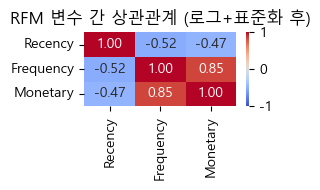

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
sns.heatmap(
    rfm_scaled[feature_names].corr(),
    vmin=-1, vmax=1,          # 음의 상관 표시 필수
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('RFM 변수 간 상관관계 (로그+표준화 후)')
plt.tight_layout()
plt.show()

k=4 부근부터 완만한 감소 구간

k= 2 | inertia=   8698.0 | silhouette=0.4345
k= 3 | inertia=   6513.9 | silhouette=0.3450
k= 4 | inertia=   4993.7 | silhouette=0.3657
k= 5 | inertia=   4230.3 | silhouette=0.3304
k= 6 | inertia=   3684.5 | silhouette=0.3290
k= 7 | inertia=   3302.1 | silhouette=0.3028
k= 8 | inertia=   3010.8 | silhouette=0.2923
k= 9 | inertia=   2755.6 | silhouette=0.2900
k=10 | inertia=   2564.7 | silhouette=0.2865

Elbow 기준 k: 4
Silhouette 기준 k: 2
최종 선택 k: 4


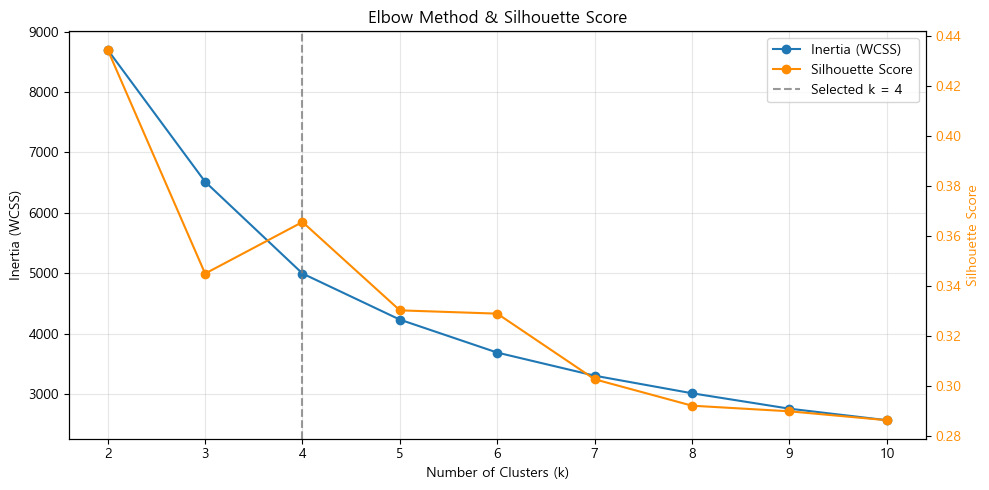

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

X = rfm_scaled[feature_names]
k_range = list(range(2, 11))

inertias = []
silhouettes = []

# =========================
# K별 평가
# =========================
for k in k_range:
    km = KMeans(
        n_clusters=k,      # 루프 변수 사용
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X, labels)
    )

    print(
        f"k={k:2d} | "
        f"inertia={km.inertia_:9.1f} | "
        f"silhouette={silhouettes[-1]:.4f}"
    )

# =========================
# Elbow 기준
# =========================
knee = KneeLocator(
    k_range,
    inertias,
    curve='convex',
    direction='decreasing'
)

elbow_k = knee.elbow

# =========================
# Silhouette 기준
# =========================
silhouette_k = k_range[np.argmax(silhouettes)]

# =========================
# 최종 k 선택
# =========================
if elbow_k is not None:

    elbow_idx = k_range.index(elbow_k)

    max_sil = max(silhouettes)
    elbow_sil = silhouettes[elbow_idx]

    # Elbow 지점의 실루엣이 최대값의 70% 이상이면 채택
    if elbow_sil >= max_sil * 0.70:
        best_k = elbow_k
    else:
        best_k = silhouette_k

else:
    best_k = silhouette_k


print(f"\nElbow 기준 k: {elbow_k}")
print(f"Silhouette 기준 k: {silhouette_k}")
print(f"최종 선택 k: {best_k}")


# =========================
# 하나의 그래프에 표시
# =========================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow / Inertia
line1 = ax1.plot(
    k_range,
    inertias,
    'o-',
    label='Inertia (WCSS)'
)

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)

# 오른쪽 y축 생성
ax2 = ax1.twinx()

# Silhouette - 주황색
line2 = ax2.plot(
    k_range,
    silhouettes,
    'o-',
    color='darkorange',
    label='Silhouette Score'
)

ax2.set_ylabel(
    'Silhouette Score',
    color='darkorange'
)

ax2.tick_params(
    axis='y',
    labelcolor='darkorange'
)

# 최종 선택 k 표시
ax1.axvline(
    best_k,
    linestyle='--',
    color='gray',
    alpha=0.8,
    label=f'Selected k = {best_k}'
)

# 범례 합치기
lines = line1 + line2
labels = [line.get_label() for line in lines]

selected_line = ax1.get_lines()[-1]
lines.append(selected_line)
labels.append(selected_line.get_label())

ax1.legend(
    lines,
    labels,
    loc='best'
)

plt.title('Elbow Method & Silhouette Score')
plt.tight_layout()
plt.show()

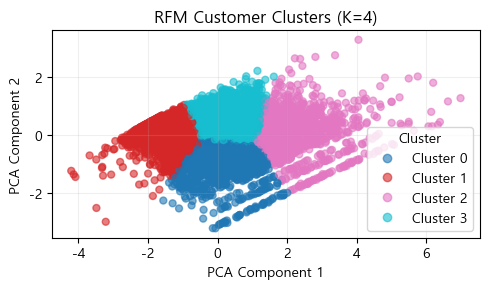

PCA 설명분산: [0.748 0.201]
누적 설명분산: 0.949


In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# 1. 최적 k로 KMeans 학습
# =========================
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

# RFM 데이터에 군집 번호 저장
rfm_cluster['cluster_4'] = labels


# =========================
# 2. PCA로 RFM 3차원 → 2차원 축소
# =========================
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# =========================
# 3. 산점도
# =========================
plt.figure(figsize=(5, 3))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6,
    s=25
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'RFM Customer Clusters (K={4})')

plt.legend(
    scatter.legend_elements()[0],
    [f'Cluster {i}' for i in range(4)],
    title='Cluster'
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# PCA가 원래 RFM 정보를 얼마나 설명하는지
print(
    'PCA 설명분산:',
    pca.explained_variance_ratio_.round(3)
)

print(
    '누적 설명분산:',
    pca.explained_variance_ratio_.sum().round(3)
)

# PC1은 Frequency와 Monetary가 높고 Recency가 낮을수록 증가하므로, 고객의 종합적인 구매가치·활성도를 나타내는 축으로 해석

In [11]:
print(rfm_cluster['cluster_4'].nunique())   # 4

4


In [12]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

print(loadings)

                PC1       PC2
Recency   -0.492583  0.867821
Frequency  0.621393  0.298284
Monetary   0.609289  0.397384


In [13]:
rfm_compare = rfm_cluster.copy()

for k in [4, 5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    rfm_compare[f'cluster_{k}'] = km.fit_predict(X)

    profile = (
        rfm_compare
        .groupby(f'cluster_{k}')
        .agg(
            고객수=('Customer ID', 'count'),
            R=('Recency', 'mean'),
            F=('Frequency', 'mean'),
            M=('Monetary', 'mean')
        )
        .round(1)
    )

    print(f"\n=== k={k} ===")
    print(profile.sort_values('M', ascending=False))


=== k=4 ===
            고객수      R     F        M
cluster_4                            
2          1116   27.2  19.4  10379.2
3          1517  212.1   5.1   1828.0
0          1159   22.7   3.0    813.2
1          2015  380.4   1.4    313.7

=== k=5 ===
            고객수      R     F        M
cluster_5                            
1           542   16.0  28.5  16892.6
3          1183   64.3   8.9   3356.3
0          1366  286.5   3.5   1191.2
2          1092   23.7   2.7    715.2
4          1624  395.8   1.2    244.0


In [14]:
print(df_train.loc[df_train['Quantity'] > 20000, 
                   ['Invoice','StockCode','Quantity','InvoiceDate','Customer ID']])

       Invoice StockCode  Quantity         InvoiceDate Customer ID
550441  541431     23166     74215 2011-01-18 10:01:00       12346


,Recency,Frequency,Monetary
cluster_4,,,
0,-0.990,-0.301,-0.219
1,0.838,-0.861,-0.920
2,-1.048,1.543,1.357
3,0.414,0.239,0.391


cluster_4
0    1159
1    2015
2    1116
3    1517
Name: count, dtype: int64


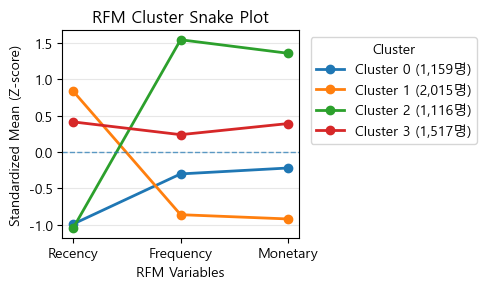

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 표준화된 RFM 데이터에 Customer ID 추가
# ==========================================

snake_df = rfm_scaled[feature_names].copy()
snake_df['Customer ID'] = rfm_cluster['Customer ID'].values

# ==========================================
# 2. Customer ID 기준으로 cluster_4 병합
# ==========================================

snake_df = snake_df.merge(
    rfm_cluster[['Customer ID', 'cluster_4']],
    on='Customer ID',
    how='left',
    validate='one_to_one'
)

# 병합 이상 여부 확인
assert snake_df['cluster_4'].notna().all(), \
    "일부 Customer ID에 cluster가 매칭되지 않았습니다."

# ==========================================
# 3. 클러스터별 표준화 RFM 평균
# ==========================================

snake_mean = (
    snake_df
    .groupby('cluster_4')[feature_names]
    .mean()
)

display(snake_mean.round(3))


# ==========================================
# 4. 클러스터별 고객 수
# ==========================================

cluster_counts = (
    snake_df['cluster_4']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


# ==========================================
# 5. Snake Plot
# ==========================================

plt.figure(figsize=(5, 3))

x = range(len(feature_names))

for cluster in snake_mean.index:

    values = snake_mean.loc[cluster, feature_names]
    n = cluster_counts.loc[cluster]

    plt.plot(
        x,
        values,
        marker='o',
        linewidth=2,
        label=f'Cluster {cluster} ({n:,}명)'
    )

# 표준화 평균 기준선
plt.axhline(
    0,
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

plt.xticks(
    x,
    feature_names
)

plt.ylabel('Standardized Mean (Z-score)')
plt.xlabel('RFM Variables')
plt.title('RFM Cluster Snake Plot')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [16]:
cluster_name_map = {
    0: 'New / Promising',
    1: 'Lost',
    2: 'Champions',
    3: 'At Risk',
}


rfm_cluster['Segment'] = rfm_cluster['cluster_4'].map(cluster_name_map)

In [17]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ============================================================
# 0. 기본 설정
# ============================================================
N_CLUSTERS = 4
RANDOM_STATE = 42
EPSILON = 1e-8

required_cols = [
    'Invoice',
    'InvoiceDate',
    'Customer ID',
    'Quantity',
    'Price',
    'Sales'
]

missing_cols = [
    col for col in required_cols
    if col not in df_train.columns
]

if missing_cols:
    raise ValueError(
        f"df_train에 필요한 칼럼이 없습니다: {missing_cols}"
    )


# ============================================================
# 1. 거래 데이터 준비
# ============================================================
tx = df_train[required_cols].copy()

tx['Invoice'] = (
    tx['Invoice']
    .astype(str)
    .str.strip()
)

tx['InvoiceDate'] = pd.to_datetime(
    tx['InvoiceDate'],
    errors='coerce'
)

tx['Quantity'] = pd.to_numeric(
    tx['Quantity'],
    errors='coerce'
)

tx['Price'] = pd.to_numeric(
    tx['Price'],
    errors='coerce'
)

tx['Sales'] = pd.to_numeric(
    tx['Sales'],
    errors='coerce'
)

tx = tx.dropna(
    subset=[
        'InvoiceDate',
        'Customer ID',
        'Quantity',
        'Price',
        'Sales'
    ]
).copy()

# 고객 ID 표현 통일
tx['Customer ID'] = (
    tx['Customer ID']
    .astype(str)
)

# 월 단위
tx['YearMonth'] = (
    tx['InvoiceDate']
    .dt.to_period('M')
)

# 정상 구매 여부
tx['is_purchase'] = (
    ~tx['Invoice'].str.startswith('C')
    & (tx['Quantity'] > 0)
)

print("거래 데이터 준비 완료")
print("거래 행 수:", len(tx))
print("고객 수:", tx['Customer ID'].nunique())
print(
    "기간:",
    tx['InvoiceDate'].min(),
    "~",
    tx['InvoiceDate'].max()
)


# ============================================================
# 2. 고객 × 월 순매출 및 순수량 집계
# ============================================================
monthly_net = (
    tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_sales=('Sales', 'sum'),
        monthly_quantity=('Quantity', 'sum')
    )
)

# 화폐 및 수량 계산 오차 정리
monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .round(2)
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .round(6)
)

monthly_net['monthly_sales'] = (
    monthly_net['monthly_sales']
    .mask(
        monthly_net['monthly_sales'].abs() < EPSILON,
        0
    )
)

monthly_net['monthly_quantity'] = (
    monthly_net['monthly_quantity']
    .mask(
        monthly_net['monthly_quantity'].abs() < EPSILON,
        0
    )
)


# ============================================================
# 3. 정상 구매 기준 월별 주문 횟수와 마지막 구매일
# ============================================================
purchase_tx = tx[
    tx['is_purchase']
].copy()

if purchase_tx.empty:
    raise ValueError(
        "정상 구매 거래가 없습니다."
    )

monthly_purchase = (
    purchase_tx
    .groupby(
        ['Customer ID', 'YearMonth'],
        as_index=False
    )
    .agg(
        monthly_orders=('Invoice', 'nunique'),
        monthly_last_purchase=('InvoiceDate', 'max')
    )
)

monthly = monthly_net.merge(
    monthly_purchase,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

monthly['monthly_orders'] = (
    monthly['monthly_orders']
    .fillna(0)
    .astype(int)
)


# ============================================================
# 4. 고객별 최초 구매월부터 마지막 관측월까지 패널 생성
# ============================================================
first_purchase_month = (
    purchase_tx
    .groupby('Customer ID')['YearMonth']
    .min()
)

last_observed_month = (
    tx['YearMonth']
    .max()
)

panel_parts = []

for customer_id, start_month in first_purchase_month.items():

    customer_months = pd.period_range(
        start=start_month,
        end=last_observed_month,
        freq='M'
    )

    customer_panel = pd.DataFrame({
        'Customer ID': customer_id,
        'YearMonth': customer_months
    })

    panel_parts.append(customer_panel)

panel = pd.concat(
    panel_parts,
    ignore_index=True
)

panel = panel.merge(
    monthly,
    on=['Customer ID', 'YearMonth'],
    how='left',
    validate='one_to_one'
)

fill_zero_cols = [
    'monthly_sales',
    'monthly_quantity',
    'monthly_orders'
]

panel[fill_zero_cols] = (
    panel[fill_zero_cols]
    .fillna(0)
)

panel['monthly_sales'] = (
    panel['monthly_sales']
    .round(2)
)

panel['monthly_quantity'] = (
    panel['monthly_quantity']
    .round(6)
)

panel['monthly_orders'] = (
    panel['monthly_orders']
    .astype(int)
)

panel = (
    panel
    .sort_values(
        ['Customer ID', 'YearMonth']
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. Recency 계산
# ============================================================
panel['last_purchase_date'] = (
    panel
    .groupby('Customer ID')[
        'monthly_last_purchase'
    ]
    .ffill()
)

# 날짜와 시간을 날짜 단위로 통일
panel['last_purchase_date'] = (
    pd.to_datetime(
        panel['last_purchase_date'],
        errors='coerce'
    )
    .dt.normalize()
)

panel['month_end'] = (
    panel['YearMonth']
    .dt.to_timestamp(how='end')
    .dt.normalize()
)

panel['Recency'] = (
    panel['month_end']
    - panel['last_purchase_date']
).dt.days

negative_recency_count = (
    panel['Recency']
    .dropna()
    .lt(0)
    .sum()
)

if negative_recency_count > 0:
    raise ValueError(
        f"음수 Recency가 {negative_recency_count}건 있습니다."
    )


# ============================================================
# 6. 누적 Frequency 및 Monetary 계산
# ============================================================
panel['Frequency'] = (
    panel
    .groupby('Customer ID')[
        'monthly_orders'
    ]
    .cumsum()
)

panel['Monetary'] = (
    panel
    .groupby('Customer ID')[
        'monthly_sales'
    ]
    .cumsum()
    .round(2)
)

# 사실상 0인 부동소수점 오차 제거
panel['Monetary'] = (
    panel['Monetary']
    .mask(
        panel['Monetary'].abs() < EPSILON,
        0
    )
)

print("\nMonetary 최소값:")
print(panel['Monetary'].min())

print(
    "사실상 0인 Monetary 수:",
    (panel['Monetary'].abs() < EPSILON).sum()
)


# ============================================================
# 7. 월별 행동 변수 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

# YearMonth가 2010-06일 경우:
# lag_1 = 2010-06
# lag_2 = 2010-05
# lag_3 = 2010-04

panel['sales_lag_1'] = (
    panel['monthly_sales']
)

panel['sales_lag_2'] = (
    customer_group['monthly_sales']
    .shift(1)
)

panel['sales_lag_3'] = (
    customer_group['monthly_sales']
    .shift(2)
)

panel['orders_lag_1'] = (
    panel['monthly_orders']
)

panel['orders_lag_2'] = (
    customer_group['monthly_orders']
    .shift(1)
)

panel['orders_lag_3'] = (
    customer_group['monthly_orders']
    .shift(2)
)

panel['quantity_lag_1'] = (
    panel['monthly_quantity']
)


# ============================================================
# 8. 고객 활동 기간과 계절 변수
# ============================================================
panel['first_purchase_month'] = (
    panel
    .groupby('Customer ID')[
        'YearMonth'
    ]
    .transform('min')
)

panel['customer_tenure'] = (
    (
        panel['YearMonth'].dt.year
        - panel['first_purchase_month'].dt.year
    ) * 12
    +
    (
        panel['YearMonth'].dt.month
        - panel['first_purchase_month'].dt.month
    )
)

panel['month'] = (
    panel['YearMonth']
    .dt.month
)


# ============================================================
# 9. 다음 달 타깃 생성
# ============================================================
customer_group = panel.groupby(
    'Customer ID',
    group_keys=False
)

panel['target_next_sales'] = (
    customer_group['monthly_sales']
    .shift(-1)
)

panel['next_month_orders'] = (
    customer_group['monthly_orders']
    .shift(-1)
)

panel['target_next_purchase'] = np.where(
    panel['next_month_orders'].isna(),
    np.nan,
    (
        panel['next_month_orders'] > 0
    ).astype(int)
)

# 다음 달 정답이 없는 마지막 관측월 제거
panel_model = panel[
    panel['target_next_sales'].notna()
].copy()

panel_model['target_next_sales'] = (
    panel_model['target_next_sales']
    .round(2)
)

panel_model['target_next_purchase'] = (
    panel_model['target_next_purchase']
    .astype(int)
)


# ============================================================
# 10. RFM 군집화 대상 생성
# ============================================================
segment_features = [
    'Recency',
    'Frequency',
    'Monetary'
]

segment_mask = (
    panel_model[segment_features]
    .notna()
    .all(axis=1)
    & (panel_model['Recency'] >= 0)
    & (panel_model['Frequency'] > 0)
    & (panel_model['Monetary'] > EPSILON)
)

segment_data = (
    panel_model
    .loc[
        segment_mask,
        segment_features
    ]
    .astype(float)
    .copy()
)

if len(segment_data) < N_CLUSTERS:
    raise ValueError(
        "군집화할 고객-월 데이터가 너무 적습니다."
    )

print("\nRFM 군집화 대상")
print("대상 행 수:", len(segment_data))
print(segment_data.describe().round(2))


# ── Step 11~12 교체: 로그변환 + fit(≤2011-09만) / predict(전체) ──
SEG_FIT_LAST = pd.Period('2011-09', 'M')
fit_mask = segment_mask & (panel_model['YearMonth'] <= SEG_FIT_LAST)

seg_all = np.log1p(panel_model.loc[segment_mask, segment_features].astype(float))
seg_fit = np.log1p(panel_model.loc[fit_mask,     segment_features].astype(float))

# 유한값 검증 (기존 로직 유지, seg_all 대상)
if not np.isfinite(seg_all.to_numpy(dtype=float)).all():
    raise ValueError("RFM 로그 데이터에 NaN/무한값이 있습니다.")

print("로그 변환 후 왜도\n", seg_fit.skew())

segment_scaler = StandardScaler().fit(seg_fit)
segment_kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
segment_kmeans.fit(segment_scaler.transform(seg_fit))

panel_model['cluster_4'] = pd.Series(pd.NA, index=panel_model.index, dtype='Int64')
panel_model.loc[segment_mask, 'cluster_4'] = segment_kmeans.predict(
    segment_scaler.transform(seg_all))


# ============================================================
# 13. 군집 프로필 출력
# ============================================================
segment_profile = (
    panel_model
    .dropna(subset=['cluster_4'])
    .groupby('cluster_4')
    .agg(
        고객월수=('Customer ID', 'size'),
        고유고객수=('Customer ID', 'nunique'),
        R=('Recency', 'mean'),
        F=('Frequency', 'mean'),
        M=('Monetary', 'mean')
    )
    .round(1)
    .sort_values(
        'M',
        ascending=False
    )
)

print("\n=== 월별 RFM 군집 프로필 ===")
print(segment_profile)

거래 데이터 준비 완료
거래 행 수: 774690
고객 수: 5844
기간: 2009-12-01 07:45:00 ~ 2011-11-29 18:19:00

Monetary 최소값:
-1663.06
사실상 0인 Monetary 수: 222

RFM 군집화 대상
대상 행 수: 86027
        Recency  Frequency   Monetary
count  86027.00   86027.00   86027.00
mean     131.32       4.52    2001.31
std      136.24       8.77    9380.29
min        0.00       1.00       1.15
25%       27.00       1.00     286.95
50%       81.00       2.00     638.20
75%      196.00       5.00    1598.90
max      699.00     330.00  551592.02
로그 변환 후 왜도
 Recency     -0.707428
Frequency    1.274313
Monetary     0.283716
dtype: float64

=== 월별 RFM 군집 프로필 ===
            고객월수  고유고객수      R     F       M
cluster_4                                   
3          12910   1608   26.1  15.9  8698.3
2          24112   2951  136.3   4.3  1620.0
0          16188   5525   19.0   2.2   678.2
1          32817   3817  224.5   1.3   299.5


In [18]:
# ============================================================
# 14. 군집 번호에 세그먼트 이름 부여 (번호 자동 유도)
# ============================================================
prof = (panel_model.dropna(subset=['cluster_4'])
        .groupby('cluster_4')[['Recency','Frequency','Monetary']].mean())

names, rest = {}, list(prof.index)

c = prof.loc[rest, 'Monetary'].idxmax(); names[c] = 'Champions'; rest.remove(c)
c = prof.loc[rest, 'Recency'].idxmax();  names[c] = 'Lost';      rest.remove(c)
# 남은 2개: Recency 큰 쪽 At Risk, 작은 쪽 New / Promising
c = prof.loc[rest, 'Recency'].idxmax();  names[c] = 'At Risk';   rest.remove(c)

names[rest[0]] = 'New / Promising'
rest.remove(rest[0])
assert not rest, f"이름 없이 남은 클러스터: {rest} — N_CLUSTERS와 명명 단계 수 불일치"

panel_cluster_name_map = names
panel_model['Segment'] = panel_model['cluster_4'].map(panel_cluster_name_map)

print("=== 유도된 매핑 ===")
for k, v in sorted(names.items()):
    print(f"cluster {k} → {v}")
print("\n=== 프로필 (검증용) ===")
print(prof.assign(Segment=prof.index.map(names))
          .sort_values('Monetary', ascending=False).round(1))
print("\n=== 세그먼트 분포 ===")
print(panel_model['Segment'].value_counts(dropna=False))

=== 유도된 매핑 ===
cluster 0 → New / Promising
cluster 1 → Lost
cluster 2 → At Risk
cluster 3 → Champions

=== 프로필 (검증용) ===
           Recency  Frequency  Monetary          Segment
cluster_4                                               
3             26.1       15.9    8698.3        Champions
2            136.3        4.3    1620.0          At Risk
0             19.0        2.2     678.2  New / Promising
1            224.5        1.3     299.5             Lost

=== 세그먼트 분포 ===
Segment
Lost               32817
At Risk            24112
New / Promising    16188
Champions          12910
NaN                  273
Name: count, dtype: int64


In [19]:
nan_rows = panel_model[
    panel_model['Segment'].isna()
].copy()

print("NaN 행 수:", len(nan_rows))

print(
    nan_rows[
        ['Recency', 'Frequency', 'Monetary']
    ].describe()
)

print("\n제외 원인")
print({
    'Recency 결측': nan_rows['Recency'].isna().sum(),
    'Recency 음수': (nan_rows['Recency'] < 0).sum(),
    'Frequency 0 이하': (nan_rows['Frequency'] <= 0).sum(),
    'Monetary 0 이하': (nan_rows['Monetary'] <= EPSILON).sum()
})

NaN 행 수: 273
          Recency   Frequency     Monetary
count  273.000000  273.000000   273.000000
mean   202.282051    1.267399  -178.581502
std    157.256737    0.746265   467.010587
min      0.000000    1.000000 -1663.060000
25%     75.000000    1.000000     0.000000
50%    168.000000    1.000000     0.000000
75%    294.000000    1.000000     0.000000
max    699.000000    4.000000     0.000000

제외 원인
{'Recency 결측': np.int64(0), 'Recency 음수': np.int64(0), 'Frequency 0 이하': np.int64(0), 'Monetary 0 이하': np.int64(273)}


## 재구매 예측 데이터 준비 (T1~T3)

**목표:** 각 고객의 "기준일 이후 4주 내 재구매 확률"을 주차별로 예측하기 위한 학습 데이터 생성

| 셀 | 역할 | 핵심 산출물 |
|----|------|------------|
| **T1** | 재구매 이벤트의 원천이 되는 **고객별 구매일 목록** 준비 | `pdates` (고객→구매일 배열), `purchases` |
| **T2** | 기준시점(origin)마다 **4주 안에 언제 재구매했는지** 라벨링 | `origin_df` (고객 1명 = 1행 + 타깃) |
| **T3** | 각 고객을 **주차별 행(1~4주)으로 확장** (생존분석 포맷) | `pp_train`, `pp_val`, `pp_test` |

### T1 — 구매일 원천
- 원본 `df`에서 정상 구매만 뽑아 **고객별 구매 날짜**를 정리
- `df_train`(10/30까지)이 아니라 **전체 `df`**(12/9까지) 사용 → test 관측창을 채우기 위해

### T2 — 타깃 생성
- origin = 기준월 말일 (예: 2011-09-30)
- 그 **다음날부터 28일** 안의 첫 재구매를 찾아 몇 주차인지(`week_of_repurchase`)와 발생 여부(`event`) 기록
- train/val/test를 **시간순으로 분리** (관측창이 서로 안 겹치게)

### T3 — person-period 확장
- 고객 1명 → 최대 10행(주차별)으로 펴기
- `week`(주차)가 새 피처, `y`(그 주에 샀나 0/1)가 학습 타깃
- **학습용**: 재구매한 주차에서 절단 / **예측용(test)**: 10주 전체
- 이 구조 덕에 누적확률 `1-Π(1-hazard)`이 **단조증가 자동 보장**

In [20]:
# ============================================================
# T1. 재구매 이벤트 원천 (원본 df 사용 — df_train 아님)
# ============================================================
from collections import defaultdict

HORIZON_DAYS = 28
N_WEEKS = 4

purchases = (
    df[df['is_purchase'] & df['Customer ID'].notna()]
    .assign(Customer_ID=lambda d: d['Customer ID'].astype(str),
            Date=lambda d: d['InvoiceDate'].dt.normalize())
    [['Customer_ID', 'Date']]
    .drop_duplicates()
    .sort_values(['Customer_ID', 'Date'])
)

# 고객별 구매일 배열 (빠른 탐색용)
pdates = defaultdict(list)
for cid, d in purchases.itertuples(index=False):
    pdates[cid].append(d)
pdates = {k: np.array(v, dtype='datetime64[ns]') for k, v in pdates.items()}

print("구매일 레코드:", len(purchases))
print("데이터 최종일:", purchases['Date'].max())   # 2011-12-09 여야 함
print("고객 수:", len(pdates))

구매일 레코드: 32878
데이터 최종일: 2011-12-09 00:00:00
고객 수: 5852


In [21]:
# ============================================================
# T2. origin 정의 + 첫 재구매 주차 계산

# ============================================================
ORIGINS = {
    # 8월 말 피처 → 9월 1~28일 정답까지 학습
    'train': pd.period_range('2010-03', '2011-08', freq='M'),

    # 9월 말 피처 → 10월 1~28일 검증
    'val': pd.PeriodIndex(['2011-09'], freq='M'),

    # 10월 말 피처 → 11월 1~28일 테스트
    'test': pd.PeriodIndex(['2011-10'], freq='M'),
}
def build_target(origin_period, split_name):
    rows = panel_model[panel_model['YearMonth'] == origin_period].copy()
    if len(rows) == 0:
        return None
    origin_end = origin_period.to_timestamp(how='end').normalize()
    win_start = origin_end + pd.Timedelta(days=1)
    win_end_exclusive = win_start + pd.Timedelta(days=HORIZON_DAYS)

    weeks, events = [], []
    for cid in rows['Customer ID'].astype(str):
        arr = pdates.get(cid)
        if arr is None:
            weeks.append(np.nan); events.append(0); continue
        nxt = arr[
    (arr >= np.datetime64(win_start)) &
    (arr < np.datetime64(win_end_exclusive))
]
        if len(nxt) == 0:
            weeks.append(np.nan); events.append(0)
        else:
            gap = (pd.Timestamp(nxt[0]) - origin_end).days
            weeks.append(int(np.ceil(gap / 7)))   # 28일이면 1~4주
            events.append(1)

    rows['week_of_repurchase'] = weeks
    rows['event'] = events
    rows['origin'] = str(origin_period)
    rows['split'] = split_name
    return rows

parts = []
for split, periods in ORIGINS.items():
    for p in periods:
        r = build_target(p, split)
        if r is not None:
            parts.append(r)

origin_df = pd.concat(parts, ignore_index=True)

# Segment NaN(Monetary<=0) 제외 — CatBoost 범주형 NaN 방지
origin_df = origin_df[origin_df['Segment'].notna()].reset_index(drop=True)

print("origin 행 수:", len(origin_df))
print("\nsplit별 행 수 / 이벤트율")
print(origin_df.groupby('split').agg(
    n=('event','size'), event_rate=('event','mean')).round(3))
print("\ntest 주차별 첫 재구매 분포")
print(origin_df[origin_df['split']=='test']['week_of_repurchase']
      .value_counts().sort_index())

origin 행 수: 82091

split별 행 수 / 이벤트율
           n  event_rate
split                   
test    5619       0.247
train  71071       0.202
val     5401       0.195

test 주차별 첫 재구매 분포
week_of_repurchase
1.0    400
2.0    401
3.0    362
4.0    227
Name: count, dtype: int64


In [22]:
# ============================================================
# T3. person-period 확장
#   학습용: 이벤트 주차에서 절단 / 예측용: 10주 전체 그리드
# ============================================================
def expand_pp(d, n_weeks=N_WEEKS, truncate=True):
    d = d.reset_index(drop=True).copy()
    d['last_week'] = (np.where(d['event'] == 1, d['week_of_repurchase'], n_weeks)
                      if truncate else n_weeks)
    d['last_week'] = d['last_week'].astype(int)

    pp = d.loc[d.index.repeat(d['last_week'])].copy()
    pp['week'] = pp.groupby(level=0).cumcount() + 1
    pp['y'] = ((pp['event'] == 1) &
               (pp['week'] == pp['week_of_repurchase'])).astype(int)

    # 해당 주가 속한 달력 월 (성수기 포착)
    oe = pd.PeriodIndex(pp['origin'].values, freq='M').to_timestamp(how='end')
    pp['pred_month'] = np.asarray(
        (oe + pd.to_timedelta(np.asarray(pp['week']) * 7, unit='D')).month)
    return pp.reset_index(drop=True)

pp_train = expand_pp(origin_df[origin_df['split'] == 'train'])
pp_val   = expand_pp(origin_df[origin_df['split'] == 'val'])
pp_test  = expand_pp(origin_df[origin_df['split'] == 'test'], truncate=False)

print("train pp:", len(pp_train), "| hazard:", pp_train['y'].mean().round(4))
print("val   pp:", len(pp_val),   "| hazard:", pp_val['y'].mean().round(4))
print("test  pp:", len(pp_test), "(=", len(origin_df[origin_df['split']=='test'])*N_WEEKS, ")")

train pp: 260439 | hazard: 0.0551
val   pp: 19847 | hazard: 0.053
test  pp: 22476 (= 22476 )


FEATS 칼럼 정의

| 칼럼                | 의미                | 계산 기준                              | 모델에서 기대하는 역할                        |
| ----------------- | ----------------- | ---------------------------------- | ----------------------------------- |
| `Recency`         | 마지막 정상 구매 후 경과 일수 | 기준월 말일 − 최근 구매일                    | 최근 구매한 고객인지, 오래 쉬고 있는 고객인지 구분       |
| `Frequency`       | 기준월까지의 누적 주문 횟수   | 정상 구매 Invoice 수의 누적합               | 반복 구매가 많은 고객인지 측정                   |
| `Monetary`        | 기준월까지의 누적 순매출     | 월별 순매출의 누적합                        | 고객의 누적 구매 가치 측정                     |
| `sales_lag_1`     | **기준월의 순매출**      | 현재 `YearMonth`의 `monthly_sales`    | 가장 최근 월의 구매금액                       |
| `sales_lag_2`     | 기준월 직전 월의 순매출     | `monthly_sales.shift(1)`           | 1개월 전 구매금액                          |
| `sales_lag_3`     | 기준월 2개월 전의 순매출    | `monthly_sales.shift(2)`           | 2개월 전 구매금액                          |
| `orders_lag_1`    | **기준월의 주문 횟수**    | 현재 `YearMonth`의 `monthly_orders`   | 가장 최근 월의 구매 빈도                      |
| `orders_lag_2`    | 기준월 직전 월의 주문 횟수   | `monthly_orders.shift(1)`          | 1개월 전 구매 빈도                         |
| `orders_lag_3`    | 기준월 2개월 전 주문 횟수   | `monthly_orders.shift(2)`          | 2개월 전 구매 빈도                         |
| `quantity_lag_1`  | **기준월의 순수량**      | 현재 `YearMonth`의 `monthly_quantity` | 최근 월의 구매·반품 수량 규모                   |
| `customer_tenure` | 첫 구매 이후 활동 개월 수   | 기준월 − 최초 구매월                       | 신규 고객인지 장기 고객인지 구분                  |
| `month`           | 기준월의 월 번호         | `YearMonth.dt.month`               | 계절성 반영. 현재는 주석 처리되어 모델에서 제외         |
| `Segment`         | RFM 기반 고객군        | K-Means로 RFM을 4개 군집화               | Champions, Lost, At Risk 등 고객 상태 반영 |
| `week`            | 예측 기간의 주차         | 1, 2, 3, 4                         | 몇 주차의 재구매 확률인지 알려주는 시간축             |
| `pred_month`      | 기준월 다음 달의 월 번호    | origin 월의 다음 달     | 예측 기간이 5주 이상일 때 의미가 있음             |


In [23]:
# T3.5
FEATS = ['Recency','Frequency','Monetary',
         'sales_lag_1','sales_lag_2','sales_lag_3',
         'orders_lag_1','orders_lag_2','orders_lag_3',
         'quantity_lag_1','customer_tenure',#'month',
         'Segment','week','pred_month']

# Customer ID: 고객 식별자
# origin: 피처를 계산한 기준월
# split: train / val / test 구분
KEYS  = ['Customer ID','origin','split']

# | 칼럼                   | 의미               | 현재 person-period 모델에서 역할 |
# | -------------------- | ---------------- | ------------------------ |
# | `y`                  | 해당 주차에 최초 재구매했는지 | **실제 모델 정답**             |
# | `event`              | 향후 4주 내 재구매했는지   | 고객 단위 보조 정답              |
# | `week_of_repurchase` | 최초 재구매가 몇 주차인지   | `y` 생성용 보조 정답            |
LABEL = ['y','event','week_of_repurchase']

KEEP = KEYS + FEATS + LABEL

LEAK = ['target_next_purchase','target_next_sales','next_month_orders',
        'last_week','monthly_last_purchase','last_purchase_date','month_end']#최종 피처를 만들기 위한 중간 재료이거나, 정답에 해당하는 칼럼
assert not set(LEAK) & set(KEEP), '누출 컬럼 잔존'

from pathlib import Path
OUT = Path('data/processed'); OUT.mkdir(parents=True, exist_ok=True)

def save_pq(d, name, cols=KEEP, csv=False):
    d = d[[c for c in cols if c in d.columns]].copy()
    for c in d.columns:
        if isinstance(d[c].dtype, pd.PeriodDtype):
            d[c] = d[c].astype(str)
    d.to_parquet(OUT / f'{name}.parquet', index=False)
    if csv:
        d.to_csv(OUT / f'{name}.csv', index=False, encoding='utf-8-sig')
    print(f'{name}: {len(d):,}행 {d.shape[1]}열')

save_pq(origin_df, 'repurchase_origin')
save_pq(pp_train,  'pp_train')
save_pq(pp_val,    'pp_val')
save_pq(pp_test,   'pp_test')

repurchase_origin: 82,091행 17열
pp_train: 260,439행 20열
pp_val: 19,847행 20열
pp_test: 22,476행 20열


In [24]:
# ============================================================
# 15. 최종 산출물 저장 (모든 패널 + 재구매 타깃)
# ============================================================


export_cols = [
    'Customer ID','YearMonth','Recency','Frequency','Monetary','Segment',
    'sales_lag_1','sales_lag_2','sales_lag_3',
    'orders_lag_1','orders_lag_2','orders_lag_3',
    'quantity_lag_1','customer_tenure','month',
    'target_next_sales','target_next_purchase'
]
lag_cols = ['sales_lag_1','sales_lag_2','sales_lag_3',
            'orders_lag_1','orders_lag_2','orders_lag_3','quantity_lag_1']
money_cols = ['Monetary','sales_lag_1','sales_lag_2','sales_lag_3','target_next_sales']



# ── (A) 월별 분석 패널 ──────────────────────────────
cmp_ = panel_model[export_cols].sort_values(['Customer ID','YearMonth']).reset_index(drop=True)
cmp_[lag_cols] = cmp_[lag_cols].fillna(0)
cmp_[money_cols] = cmp_[money_cols].round(2)
cmp_['quantity_lag_1'] = cmp_['quantity_lag_1'].round(6)
cmp_ = cmp_.dropna(subset=['Segment']).reset_index(drop=True)


# ── 검증 ──────────────────────────────────────────
print('\n월별 패널 기간:', cmp_['YearMonth'].min(), '~', cmp_['YearMonth'].max())
print('세그먼트 분포\n', cmp_['Segment'].value_counts())
print('\norigin split별\n', origin_df.groupby('split')['event'].agg(['size','mean']).round(3))


월별 패널 기간: 2009-12 ~ 2011-10
세그먼트 분포
 Segment
Lost               32817
At Risk            24112
New / Promising    16188
Champions          12910
Name: count, dtype: int64

origin split별
         size   mean
split              
test    5619  0.247
train  71071  0.202
val     5401  0.195


In [25]:
import pandas as pd
chk = pd.read_parquet('data/processed/pp_train.parquet')
print(chk.shape)                    # (260439, 21)
print(sorted(set(LEAK) & set(chk.columns)))   # []

(260439, 20)
[]


In [26]:
tmp = tx.copy()
tmp['first_pm'] = tmp['Customer ID'].map(first_purchase_month)

no_purchase = tmp['first_pm'].isna()                    # 구매 없이 취소만 있는 고객
before_first = ~no_purchase & (tmp['YearMonth'] < tmp['first_pm'])

print('구매이력 없는 고객:', round(tmp.loc[no_purchase,'Sales'].sum(),2),
      '| 고객수', tmp.loc[no_purchase,'Customer ID'].nunique())
print('첫구매 이전 취소:', round(tmp.loc[before_first,'Sales'].sum(),2))
print('합계:', round(tmp.loc[no_purchase|before_first,'Sales'].sum(),2))
# 구매 이력이 없는 취소 전용 고객 23명과 첫 구매월 이전 반품 건은 패널에서 제외했으며, 이는 전체 순매출의 0.03% 수준이다.

구매이력 없는 고객: -1406.13 | 고객수 23
첫구매 이전 취소: -3325.17
합계: -4731.3


In [27]:
# T3 실행 후
print("train pp:", len(pp_train), "| hazard:", pp_train['y'].mean().round(4))
print("val   pp:", len(pp_val),   "| hazard:", pp_val['y'].mean().round(4))
print("test  pp:", len(pp_test), "(=", len(origin_df[origin_df['split']=='test'])*N_WEEKS, ")")


train pp: 260439 | hazard: 0.0551
val   pp: 19847 | hazard: 0.053
test  pp: 22476 (= 22476 )


In [28]:
# ============================================================
# T3.5 Person-period 데이터 저장
# ============================================================
import pandas as pd
from pathlib import Path



assert not set(LEAK) & set(KEEP), '누출 컬럼 잔존'


# ------------------------------------------------------------
# 저장 경로
# ------------------------------------------------------------
OUT = Path('data/processed')
OUT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Parquet + CSV 저장 함수
# ------------------------------------------------------------
def save_pq(d, name, cols=KEEP, csv=True):
    save_df = d[
        [c for c in cols if c in d.columns]
    ].copy()

    # Period 자료형은 문자열로 변환
    for c in save_df.columns:
        if isinstance(save_df[c].dtype, pd.PeriodDtype):
            save_df[c] = save_df[c].astype(str)

    # Parquet 저장
    parquet_path = OUT / f'{name}.parquet'
    save_df.to_parquet(parquet_path, index=False)

    # CSV 저장
    if csv:
        csv_path = OUT / f'{name}.csv'

        save_df.to_csv(
            csv_path,
            index=False,
            encoding='utf-8-sig'
        )

    print(
        f'[{name}]\n'
        f'행: {len(save_df):,}\n'
        f'열: {save_df.shape[1]}\n'
        f'CSV: {csv_path if csv else "저장 안 함"}\n'
        f'Parquet: {parquet_path}\n'
    )


# ------------------------------------------------------------
# 데이터 저장
# ------------------------------------------------------------
save_pq(origin_df, 'repurchase_origin')
save_pq(pp_train, 'pp_train')
save_pq(pp_val, 'pp_val')
save_pq(pp_test, 'pp_test')

[repurchase_origin]
행: 82,091
열: 17
CSV: data\processed\repurchase_origin.csv
Parquet: data\processed\repurchase_origin.parquet

[pp_train]
행: 260,439
열: 20
CSV: data\processed\pp_train.csv
Parquet: data\processed\pp_train.parquet

[pp_val]
행: 19,847
열: 20
CSV: data\processed\pp_val.csv
Parquet: data\processed\pp_val.parquet

[pp_test]
행: 22,476
열: 20
CSV: data\processed\pp_test.csv
Parquet: data\processed\pp_test.parquet

